In [ ]:
# 0,1: 00 for psi_1, 01 for psi_2 ...
# 2: For states
# 3,4: Ancillary qubits

# when theta = 32.56... 
# psi_1 = |0> 
# psi_2 = sqrt(2/3)|0> + sqrt(1/3)|1>
# psi_3 = sqrt(2/3)|0> - sqrt(1/3)|1>

In [1]:
from qiskit import QuantumCircuit
from numpy import sqrt

def circuit_init():
    qc = QuantumCircuit(5)
    return qc

def PREP(qc):
    desired_vector = [sqrt(1/3), 0, sqrt(2)/3, 1/3, sqrt(2)/3, -1/3, 0, 0]
    qc.initialize(desired_vector, [2,1,0])
    return qc

In [2]:
from qiskit.circuit import ParameterVector
from qiskit.circuit.library.standard_gates import RYGate
from qiskit.circuit.library import U2Gate
from numpy import pi

# U2Gate 
def AnsatzU2(qc, wires):
    
    params = ParameterVector('x', 14)
    qc.u(params[0], params[1], pi / 2, wires[0])  # Equivalent to U2

    # set RYGate
    CRY1_1=RYGate(params[2]*pi,label='θ1_1').control(1,ctrl_state='0')
    CRY2_1=RYGate(params[3]*pi,label='θ2_1').control(1,ctrl_state='1')
    CRY1_2=RYGate(params[4]*pi,label='θ1_2').control(2,ctrl_state='10')
    CRY2_2=RYGate(params[5]*pi,label='θ2_2').control(2)

    # set VGate
    V1_1 = U2Gate(params[6],params[7], label = 'V1_1').control(1,ctrl_state='0')
    V2_1 = U2Gate(params[8],params[9], label = 'V2_1').control(1,ctrl_state='1')
    V1_2 = U2Gate(params[10],params[11], label = 'V1_2').control(2,ctrl_state='10')
    V2_2 = U2Gate(params[12],params[13], label = 'V2_2').control(2)

    # module 1
    qc.append(CRY1_1, [wires[0], wires[1]])
    qc.append(CRY2_1, [wires[0], wires[1]])
    qc.append(V1_1, [wires[1], wires[0]])
    qc.append(V2_1, [wires[1], wires[0]])
    #qc.cx(wires[2], wires[1])
    qc.append(CRY1_2, [wires[0], wires[1], wires[2]])
    qc.append(CRY2_2, [wires[0], wires[1], wires[2]])
    qc.append(V1_2, [wires[2], wires[1], wires[0]])
    qc.append(V2_2, [wires[2], wires[1], wires[0]])
    
    qc.measure_all()
    return qc

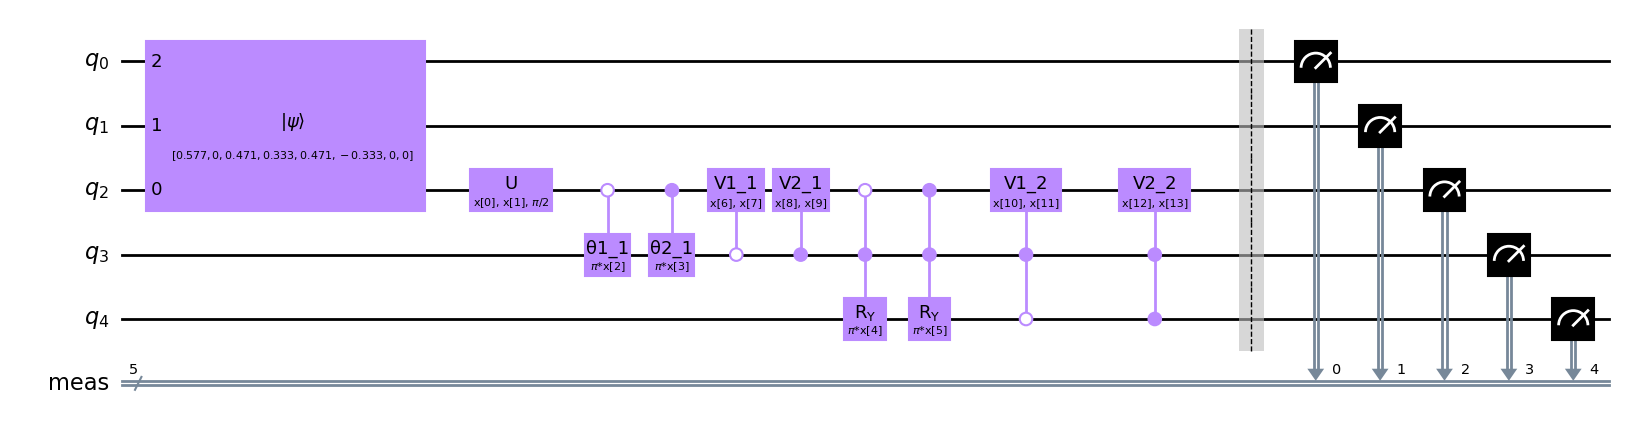

In [3]:
from numpy.random import rand
 
num_params= 14 
qc = circuit_init()
PREP(qc)
AnsatzU2(qc, [2,3,4])

qc_reversed=qc.reverse_bits()
qc.draw(output='mpl', style = 'clifford') 

<IBMBackend('ibm_strasbourg')>


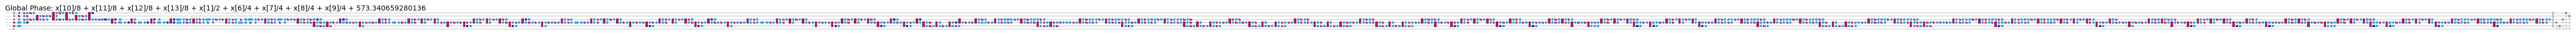

In [4]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

service = QiskitRuntimeService(channel='ibm_quantum')
#backend = service.least_busy(min_num_qubits=127)
backend = service.backend("ibm_strasbourg")
print(backend)

pm = generate_preset_pass_manager(optimization_level=3,backend=backend)


candidate_circuit = pm.run(qc_reversed)
candidate_circuit.draw('mpl', fold=False, scale=0.1, idle_wires=False)

In [5]:
from qiskit.quantum_info import SparsePauliOp

# Define the factor (I + Z)/2 = |0><0|
o_term = SparsePauliOp.from_list([("I", 0.5), ("Z", 0.5)])

# Define the factor (I - Z)/2 = |1><1|
l_term = SparsePauliOp.from_list([("I", 0.5), ("Z", -0.5)])

I = SparsePauliOp.from_list([("I", 1)])

# Use tensor products to create (I + Z)/2 ⊗ (I + Z)/2 ⊗ (I + Z)/2 ⊗ (I + Z)/2
Ob1= o_term.tensor(o_term).tensor(I).tensor(o_term).tensor(o_term)

# Check if b0b1 = 01, Check if b3b4 = 10
Ob2= o_term.tensor(l_term).tensor(I).tensor(l_term).tensor(o_term)

# Check if b0b1 = 10, Check if b3b4 = 11
Ob3= l_term.tensor(o_term).tensor(I).tensor(l_term).tensor(l_term)

cost_hamiltonian = Ob1 + Ob2 + Ob3
cost_hamiltonian=cost_hamiltonian.apply_layout(candidate_circuit.layout)

In [6]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # Prepare the job input with the ansatz, Hamiltonian, and parameters
    pub = (ansatz, hamiltonian, params)
    job = estimator.run([pub])

    # Retrieve the result
    results = job.result()[0]

    # Extract the cost (expectation value)
    cost = results.data.evs
    print('cost is', cost)

    # Append cost to the global success probability list and return it
    success_probability.append(cost)
    return 1/cost

In [7]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from scipy.optimize import minimize

init_params = rand(num_params)
success_probability = [] # Global variable

with Session(backend=backend) as session:

    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-1,
    )
    print(result)

cost is 0.18483148480600242
cost is 0.2169406275732564
cost is 0.17773341816665789
cost is 0.1644615637388351
cost is 0.17911353555313067
cost is 0.15712612678881507
cost is 0.1879954139450419
cost is 0.1966409113366078
cost is 0.19945297460941766
cost is 0.19398472086023583
cost is 0.18785498391994532
cost is 0.18528448116592605
cost is 0.1817542321578109
cost is 0.19870042158446197
cost is 0.19753828264263457
cost is 0.1574830124377286
cost is 0.18800854789743815
cost is 0.20020631943454903
cost is 0.2103463306650093
cost is 0.20296462213733532
cost is 0.20053639414974683
cost is 0.21646483312842682
cost is 0.16448120650175646
cost is 0.20835903067595962
cost is 0.20790280387079166
cost is 0.18449971292769607
cost is 0.19432403662630593
cost is 0.1790974174381247
cost is 0.19220051560642298
cost is 0.17686803658901495
cost is 0.21712531549003006
cost is 0.2023149643575248
cost is 0.18610273307284136
cost is 0.21204525156300122
cost is 0.20579204302528192
cost is 0.19866666963450977
c

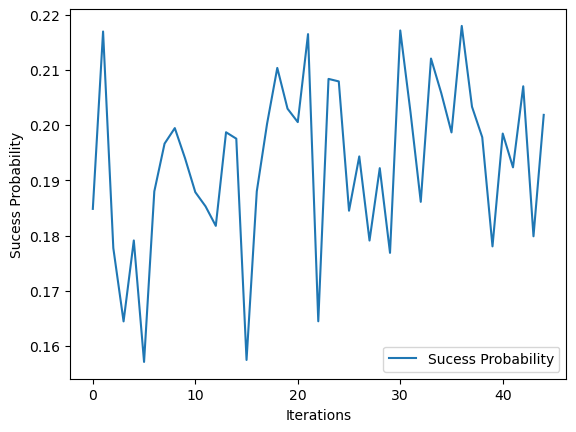

In [8]:
import matplotlib.pyplot as plt
plt.plot(success_probability, label="Sucess Probability")
plt.xlabel('Iterations')
plt.ylabel('Sucess Probability')
plt.legend()
plt.show()

In [10]:
import openpyxl

# create a new workbook
workbook = openpyxl.Workbook()

# select the active worksheet
worksheet = workbook.active

# loop through the confidences array and write values to the worksheet
for i in range(len(success_probability)):
    worksheet.cell(row=i+1, column=1, value=float(success_probability[i]))

# save the workbook to a file
workbook.save('ME Yordan Sym states tol01 (ibm_strasbourg).xlsx')